In [1]:
import torch
import torch.fft
import numpy as np
import matplotlib.pyplot as plt
import helper_functions as hlp


In [17]:
import numpy as np

# טעינת הקובץ
data = np.load('simulation_results.npz')

# גישה לפרמטרים לפי השמות שנתנו להם
t = data['time']
s_nulled = data['s_nulled']
Fs = data['Fs']
freqs = data['freqs']
S_orig_norm = data['S_orig_norm']
T = data['T']

print(f"Loaded phasor with shape: {t.shape}")


Loaded phasor with shape: (600,)


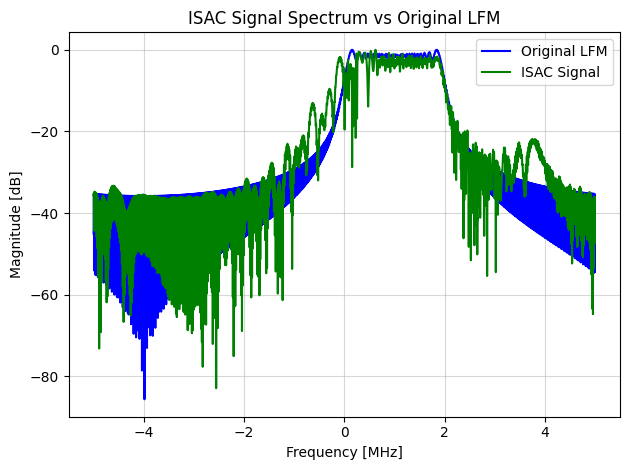

In [18]:
# OFDM signal generation
from OFDM_2 import OFDM, OFDM_demodulate
import OFDM_2

def QPSK_modulation(bits):
    """ Modulate the input bits using QPSK modulation. """
    if len(bits) % 2 != 0:
        raise ValueError("Number of bits must be even for QPSK modulation.")
    
    # bits generate
    bit_pairs = bits.reshape(-1, 2)

    # bits to QPSK symbols conversion
    symbols = np.zeros(len(bit_pairs), dtype=complex)
    for i, pair in enumerate(bit_pairs):
        if np.array_equal(pair, [0, 0]):
            symbols[i] = 1 + 1j
        elif np.array_equal(pair, [0, 1]):
            symbols[i] = 1 - 1j
        elif np.array_equal(pair, [1, 0]):
            symbols[i] = -1 + 1j
        elif np.array_equal(pair, [1, 1]):
            symbols[i] = -1 - 1j
    return symbols/np.sqrt(2) # return normalized bits

bits = np.random.randint(0, 2, 16*2)
QPSK_data = QPSK_modulation(bits)

OFDM_signal = OFDM(QPSK_data, t=t, num=16, normalize=True)
isac_signal = s_nulled + OFDM_signal

ISAC_freqs, ISAC_SIGNAL = hlp.spectrum(isac_signal, Fs, 2**14)

S_isac_db = 20*np.log10(np.abs(ISAC_SIGNAL) + 1e-15)
S_isac_norm = 20*np.log10(np.abs(ISAC_SIGNAL)/np.max(np.abs(ISAC_SIGNAL)) + 1e-400)

# plotting results in the frequency domain
plt.figure()
plt.plot(freqs/1e6, S_orig_norm, label='Original LFM', color='blue')
plt.plot(ISAC_freqs/1e6, S_isac_norm, label='ISAC Signal', color='green')
# plt.plot(freqs/1e6, S_final_norm, label='Final Signal', color='red')
plt.title("ISAC Signal Spectrum vs Original LFM")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

[ 0.70710678-0.70710678j  0.70710678-0.70710678j  0.70710678+0.70710678j
  0.70710678-0.70710678j  0.70710678+0.70710678j -0.70710678-0.70710678j
 -0.70710678+0.70710678j -0.70710678-0.70710678j  0.70710678-0.70710678j
  0.70710678+0.70710678j  0.70710678+0.70710678j  0.70710678+0.70710678j
  0.70710678-0.70710678j -0.70710678+0.70710678j -0.70710678+0.70710678j
  0.70710678-0.70710678j]
mean signal magnitude:  0.06273224497868155
Difference: [np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_]


<Figure size 600x600 with 0 Axes>

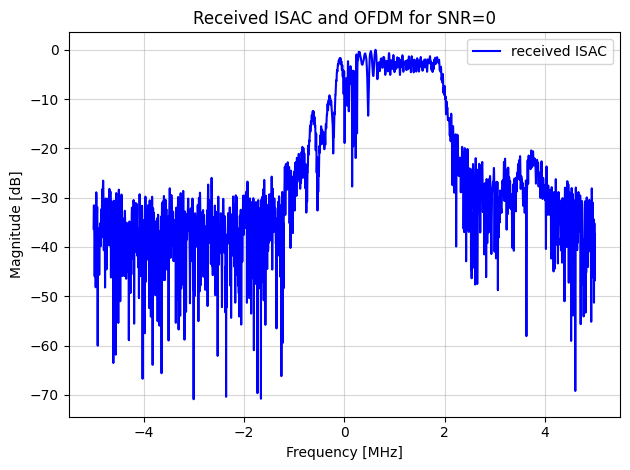

In [19]:
# Matching Receiver Designation
"""
For now, we assume a non-observable environment.
The Sensing part of the signal will only be checked by the PSLR-ISLR metrics.
"""
np.random.seed(1)


def isac_to_data (isac_signal, nulled_chirp, new=True):
    if new:
        return isac_signal
    else:
        return isac_signal - nulled_chirp

def isac_receiver(isac_signal, nulled_chirp):
    r_t = isac_to_data(isac_signal, nulled_chirp)
    return OFDM_2.OFDM_demodulate(r_t, 16)


SNR = [-4000, 0, 10, 20, 30, 40, 1000]
StC_ratio = [0.5, 1, 2] # Sensing to Communication ratio
sigma = []

plt.figure(figsize=(6, 6))

def channel (isac_signal=isac_signal, SNR_val=0, seed=1):
    np.random.seed(seed)
    print("mean signal magnitude: ", np.abs(np.mean(isac_signal)))
    sigma = np.abs(np.mean(isac_signal))/(10**(SNR_val/20))
    noise = np.random.normal(0, sigma/2, size=len(isac_signal)) + 1j*np.random.normal(0, sigma/2, size=len(isac_signal))
    
    # AWGN channel
    r_t = isac_signal + noise

    # print this
    _, R = hlp.spectrum(r_t, Fs, 2**14)
    R_norm= 20*np.log10(np.abs(R)/np.max(np.abs(R)) + 1e-400)

    plt.figure()
    plt.plot(freqs/1e6, R_norm, label='received ISAC', color='blue')
    # plt.plot(freqs/1e6, S_final_norm, label='Final Signal', color='red')
    plt.title(f"Received ISAC and OFDM for SNR={SNR_val}")
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Magnitude [dB]")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()


    return r_t

def receiver (r_t, num=16, T=T, t=t):
    t = np.array(t)
    r_t = np.array(r_t)
    fs = len(t)/T
    z_n = OFDM_demodulate(np.array(r_t), num=16, t=t, T=T)/abs(np.mean(r_t))
    return np.array(z_n)
print(QPSK_data)
received_symbols = receiver(channel(SNR_val=0), t=t, T=T)

is_different = list(np.abs(QPSK_data - received_symbols) > 0.5)
print("Difference:", is_different)
    

plt.show()





mean signal magnitude:  0.062455878788603515
mean signal magnitude:  0.062455878788603515
mean signal magnitude:  0.062455878788603515
mean signal magnitude:  0.062455878788603515
mean signal magnitude:  0.062455878788603515
mean signal magnitude:  0.062455878788603515
mean signal magnitude:  0.062455878788603515
mean signal magnitude:  0.062455878788603515
mean signal magnitude:  0.062455878788603515


<Figure size 600x600 with 0 Axes>

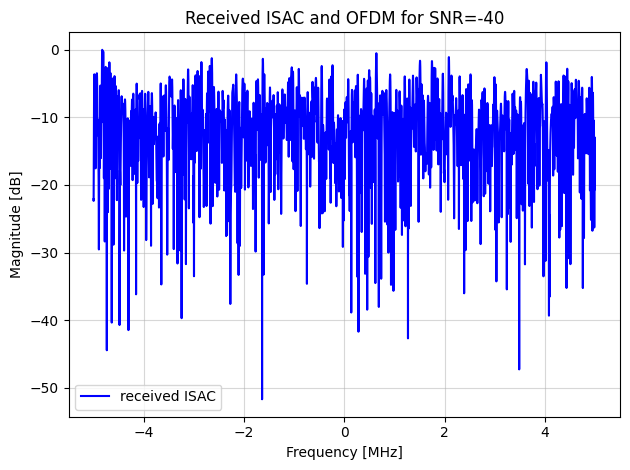

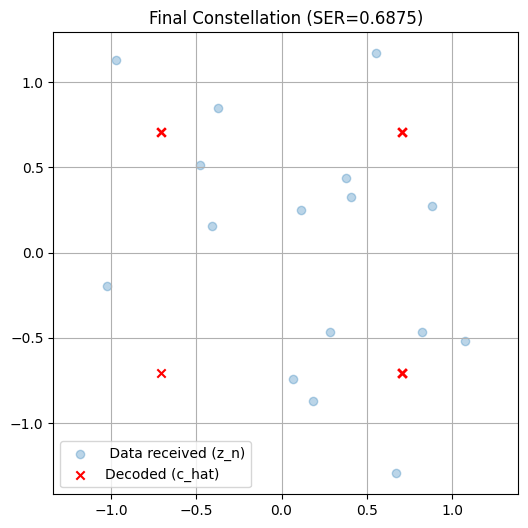

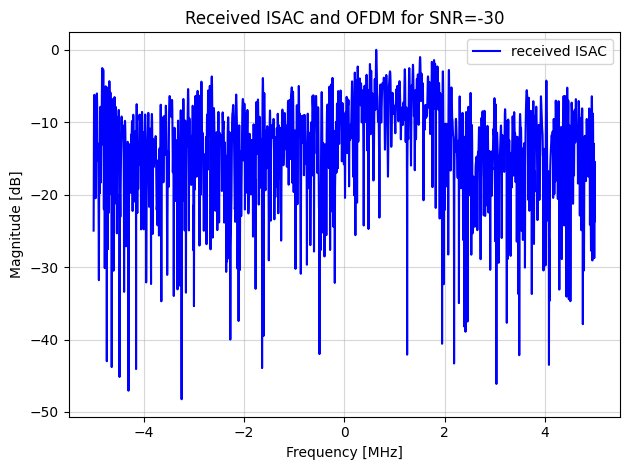

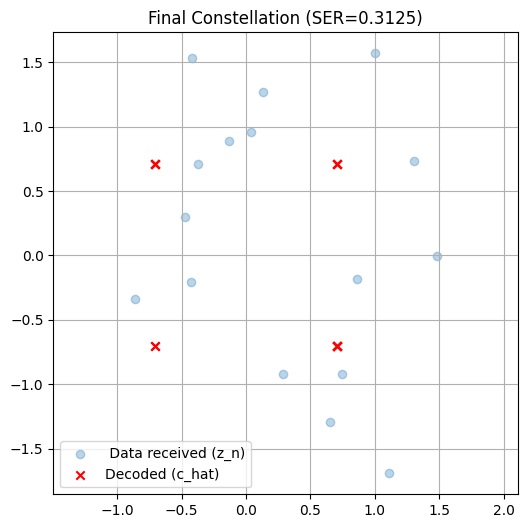

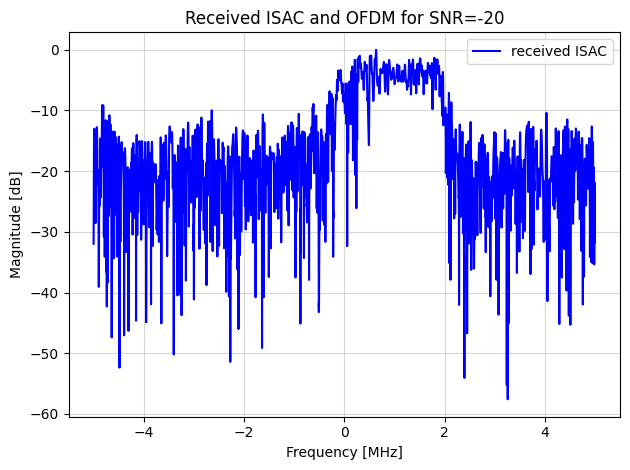

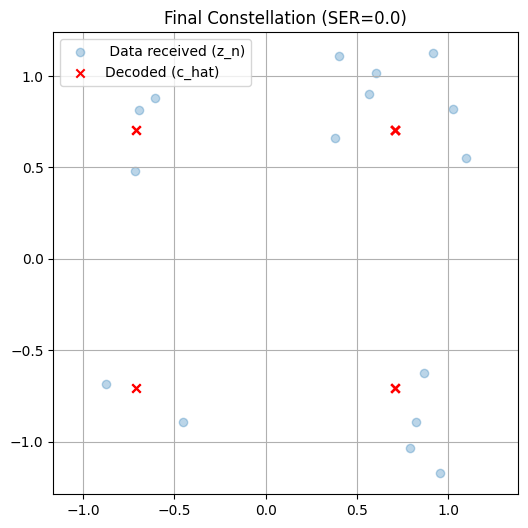

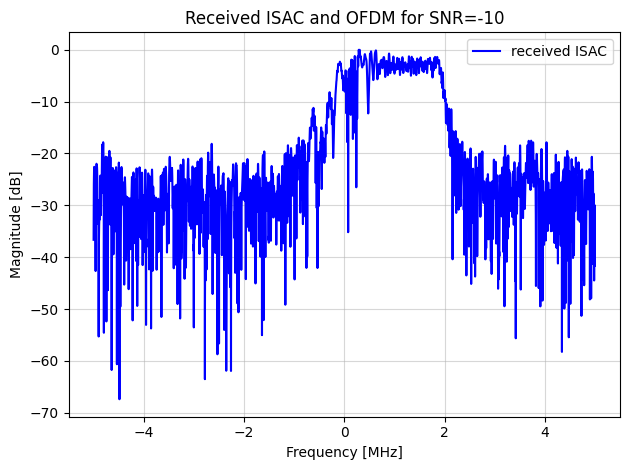

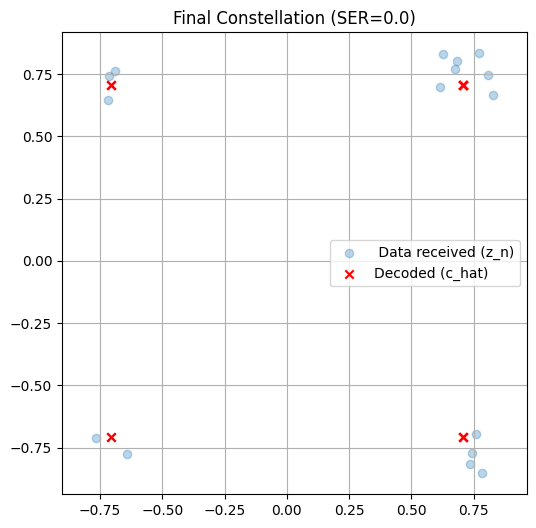

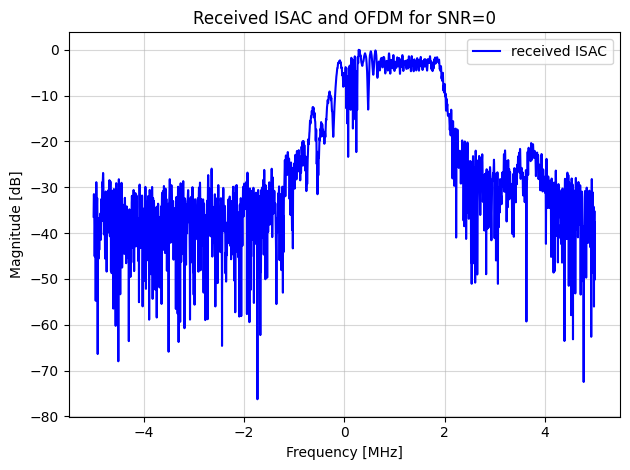

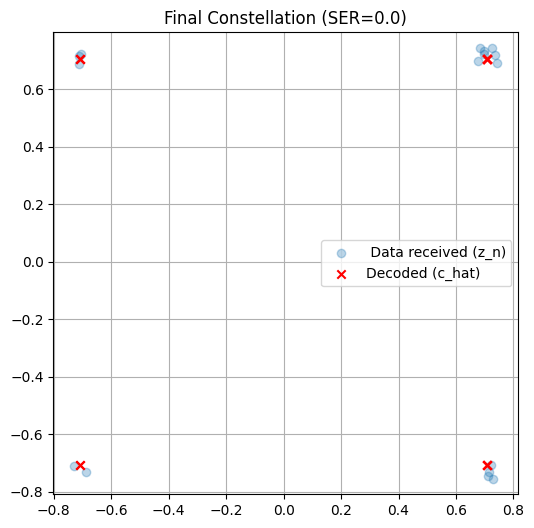

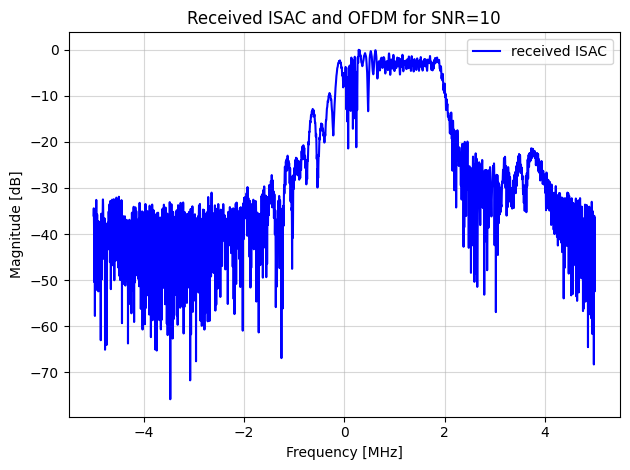

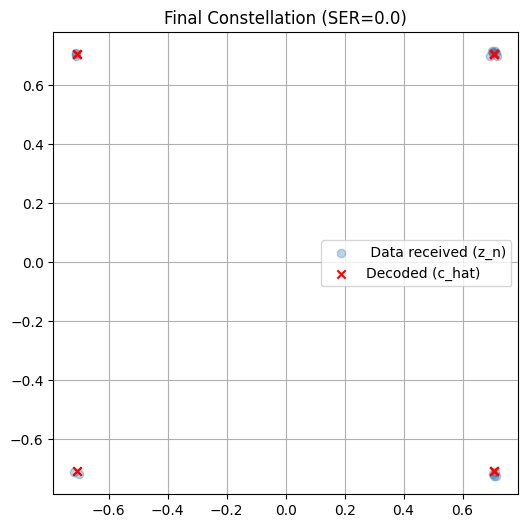

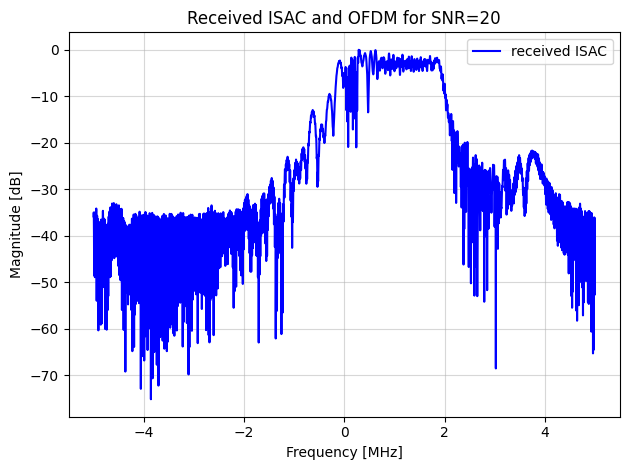

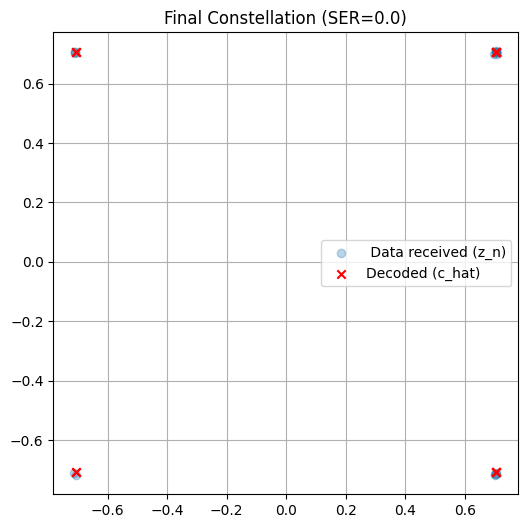

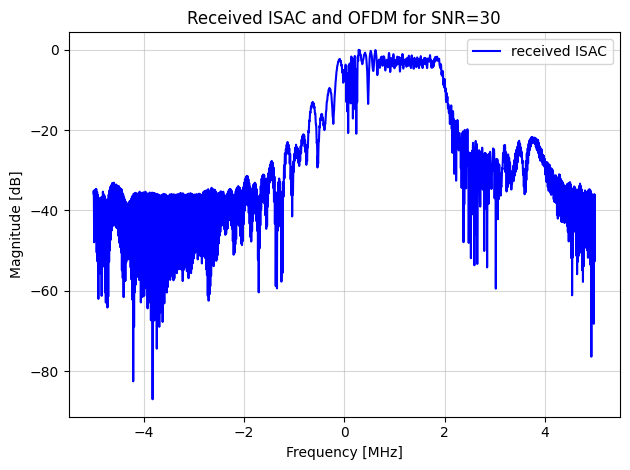

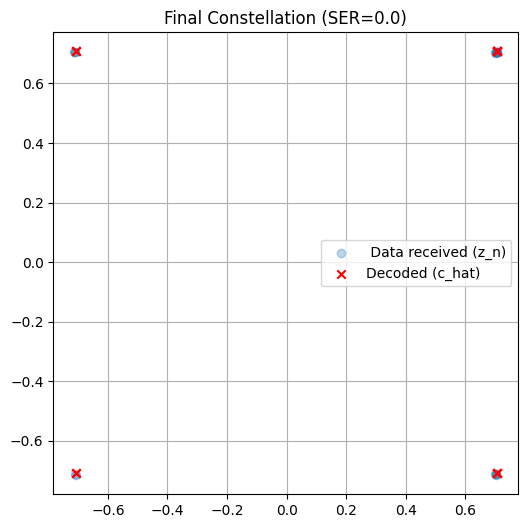

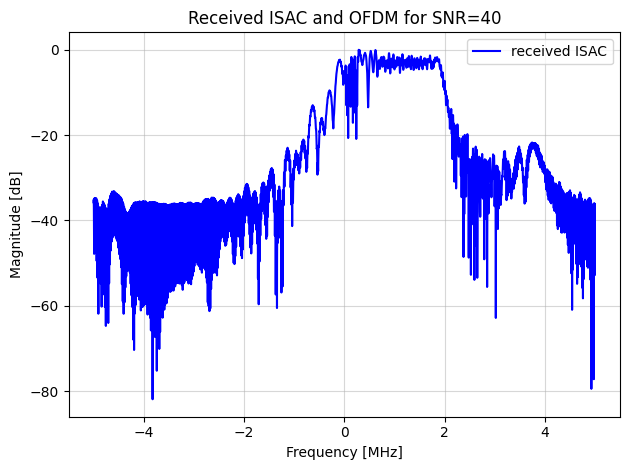

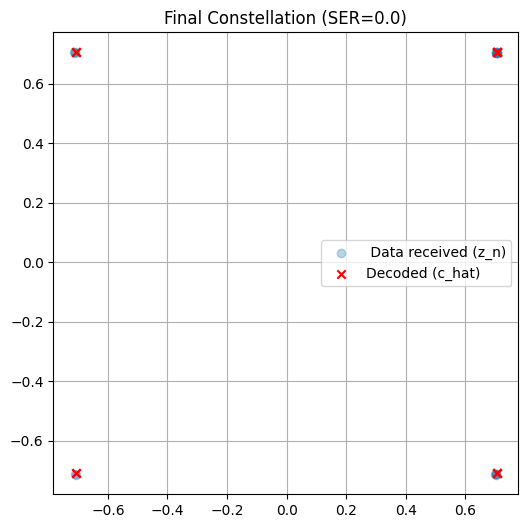

In [15]:
# Simulating ISAC
SNR = [-40, -30, -20, -10, 0, 10, 20, 30, 40]
StC_ratio = [0.5, 1, 2] # Sensing to Communication ratio
sigma = []

SER = []

plt.figure(figsize=(6, 6))

for SNR_val in SNR:
    r_t = channel(isac_signal=isac_signal, SNR_val=SNR_val)
    z_n = receiver(r_t, t=t, T=T)

    c_hat = []
    for l in range(0, 16):
        
        if np.real(z_n[l]) > 0 and np.imag(z_n[l]) > 0:
            c_hat.append((1+1j)/np.sqrt(2))

        elif np.real(z_n[l]) < 0 and np.imag(z_n[l]) > 0:
            c_hat.append((-1+1j)/np.sqrt(2))

        elif np.real(z_n[l]) > 0 and  np.imag(z_n[l]) < 0:
            c_hat.append((1-1j)/np.sqrt(2))

        elif np.real(z_n[l]) < 0 and  np.imag(z_n[l]) < 0:
            c_hat.append((-1-1j)/np.sqrt(2))

        else:
            c_hat.append((1+1j)/np.sqrt(2))

    equal_num = np.sum(QPSK_data == c_hat)
    SER_val = 1- equal_num / len(QPSK_data)
    SER.append(SER_val)

    # Plot results
    plt.figure(figsize=(6, 6))
    plt.scatter(np.real(z_n), np.imag(z_n), alpha=0.3, label=' Data received (z_n)')
    plt.scatter(np.real(c_hat), np.imag(c_hat), marker='x', color='r', label='Decoded (c_hat)')
    plt.title(f"Final Constellation (SER={SER_val})")
    plt.legend()
    plt.grid(True)
    plt.axis('equal')

plt.show()
